# E.D.A Analysis

# Exploratory data analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ldp = pd.read_csv("credit_risk_dataset.csv")

In [5]:
ldp

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1
...,...,...,...,...,...,...,...,...
995,53,44519.0,7307,433,22,PhD,Rent,1
996,22,107487.0,44901,582,7,High School,Own,1
997,34,102870.0,16205,372,29,Masters,Rent,0
998,60,66197.0,10906,780,24,PhD,Own,0


# Target variable analysis

to observe class is imbalance or not

In [6]:
ldp.columns

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years',
       'Education_Level', 'Housing_Status', 'Default'],
      dtype='object')

In [7]:
ldp['Default'].value_counts()

Default
0    862
1    138
Name: count, dtype: int64

<Axes: xlabel='Default', ylabel='count'>

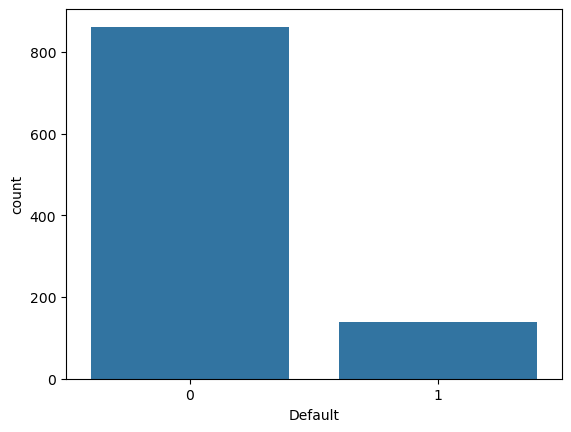

In [8]:
sns.countplot(x='Default',data=ldp)

# Numerical Feature analysis

to check distribution,skweness

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>],
       [<Axes: title={'center': 'Loan_Amount'}>,
        <Axes: title={'center': 'Credit_Score'}>],
       [<Axes: title={'center': 'Employment_Years'}>, <Axes: >]],
      dtype=object)

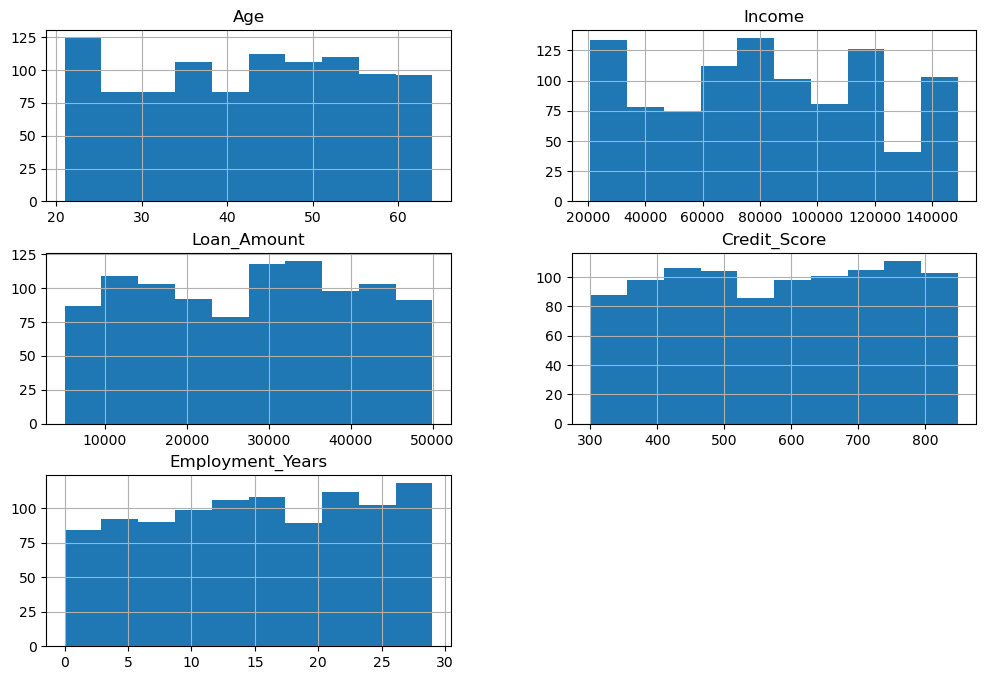

In [9]:
num_cols=['Age','Income','Loan_Amount','Credit_Score','Employment_Years']
ldp[num_cols].hist(figsize=(12,8))

# Statistical summary

In [10]:
ldp.describe()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,1000.000000,985.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,82254.047716,27729.324000,581.05000,15.164000,0.138000
std,12.611059,36842.390571,12774.836247,158.59334,8.593075,0.345073
min,21.000000,20922.000000,5097.000000,300.00000,0.000000,0.000000
25%,32.000000,52154.000000,16387.500000,441.00000,8.000000,0.000000
50%,43.000000,79379.000000,28483.500000,582.00000,15.000000,0.000000
75%,53.000000,116646.000000,38535.500000,720.25000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.00000,29.000000,1.000000


# Correlation heatmap  

feature  relationships

multicollinearity

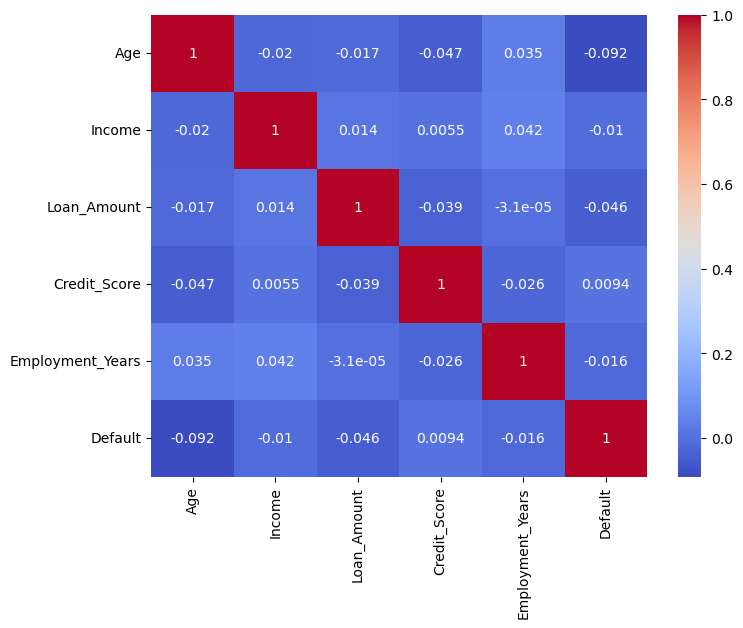

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(ldp.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

# Numerical vs default

# income default

<Axes: xlabel='Default', ylabel='Income'>

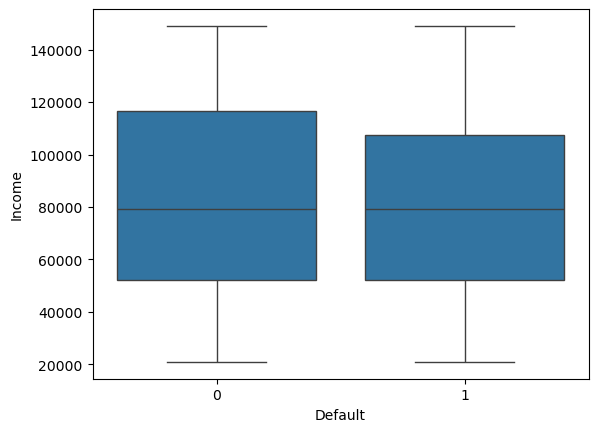

In [12]:
sns.boxplot(x='Default',y='Income',data=ldp)

# loan amount vs default

<Axes: xlabel='Default', ylabel='Loan_Amount'>

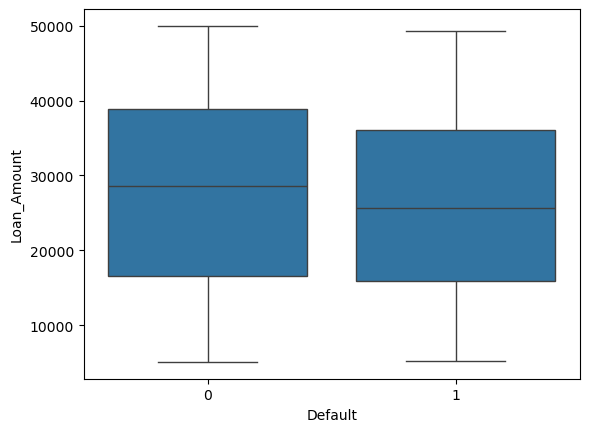

In [13]:
sns.boxplot(x='Default',y='Loan_Amount',data=ldp)

# credit score vs default

<Axes: xlabel='Default', ylabel='Credit_Score'>

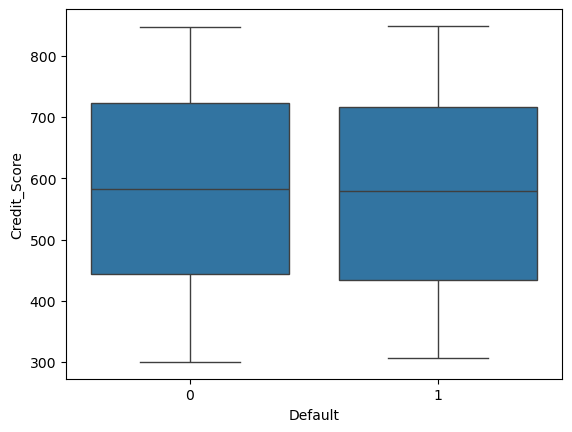

In [15]:
sns.boxplot(x='Default',y='Credit_Score',data=ldp)

# Categorical vs default

# Education level

In [16]:
pd.crosstab(ldp['Education_Level'],
            ldp['Default'])

Default,0,1
Education_Level,,
Bachelors,215,33
High School,211,28
Masters,214,39
PhD,222,38


<Axes: xlabel='Education_Level', ylabel='count'>

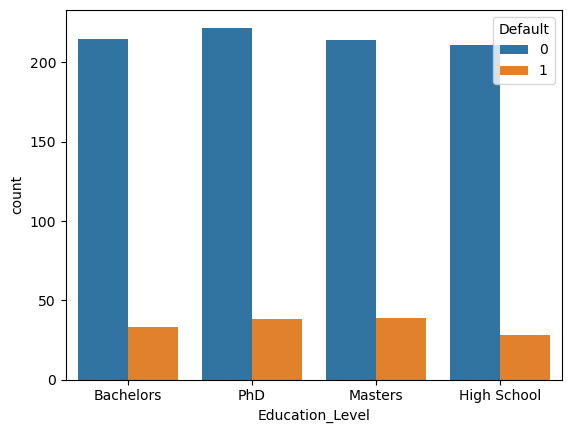

In [18]:
sns.countplot(x='Education_Level',
              hue='Default',
              data=ldp)

<Axes: xlabel='Housing_Status', ylabel='count'>

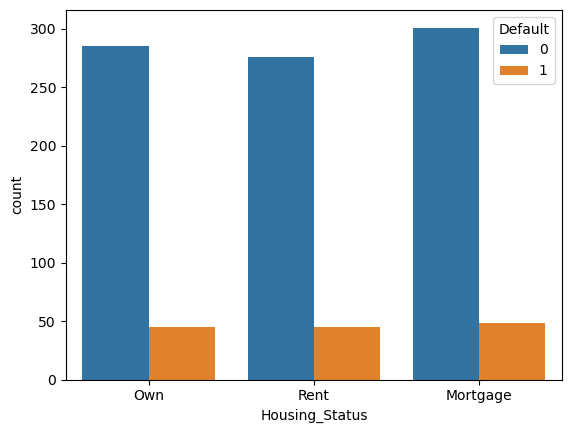

In [19]:
sns.countplot(x='Housing_Status',
             hue='Default',
             data=ldp)

# Feature engineering insight

In [20]:
ldp['Loan_Income_Ratio'] = ldp['Loan_Amount']/ldp['Income']

<Axes: xlabel='Default', ylabel='Loan_Income_Ratio'>

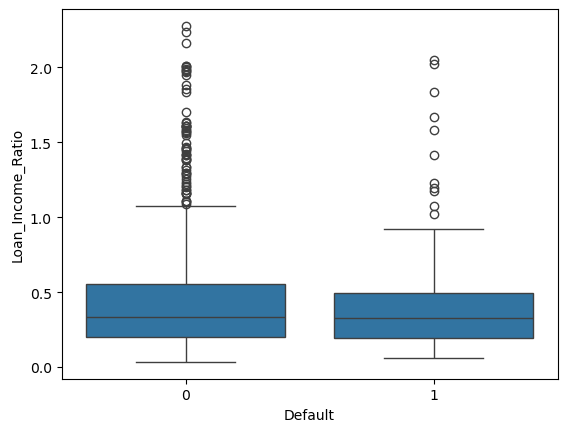

In [21]:
sns.boxplot(x='Default',
            y='Loan_Income_Ratio',
            data=ldp)